# Gemini Embedding 2 Cookbook

**Model:** `gemini-embedding-2-preview`  
**Released:** March 10, 2026  
**Provider:** Google DeepMind / Gemini API

Gemini Embedding 2 is the first natively multimodal embedding model in the Gemini API. It maps text, images, video, audio, and documents into a single unified embedding space, enabling cross-modal search and comparison across 100+ languages.

**Key specs:**
- Input modalities: text, images (PNG/JPEG), audio (MP3/WAV), video (MP4/MOV), PDFs
- Max input tokens: 8,192
- Default output dimensions: 3,072 (supports 128-3,072 via MRL)
- Recommended dimensions: 768, 1536, 3072
- 100+ languages supported

**Sections:**
0. Setup and Installation
1. Basic Usage
2. Task Types
3. Controlling Embedding Size (MRL)
4. Multimodal Embeddings
5. Semantic Search (RAG)
6. Framework Integrations
7. Building an Agent with Embeddings
8. Advanced: Cross-Modal Search
9. Batch Embeddings

## 0. Setup and Installation

In [4]:
%pip install -q google-genai numpy pandas scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
from google import genai
from google.genai import types

os.environ["GEMINI_API_KEY"] = "Enter key here"
client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

MODEL = "gemini-embedding-2-preview"

## 1. Basic Usage

Generate an embedding for a single text string. The result is a 3,072-dimensional vector by default.

In [6]:
result = client.models.embed_content(
    model=MODEL,
    contents="What is the meaning of life?"
)

embedding = result.embeddings[0]
print(f"Embedding dimensions: {len(embedding.values)}")
print(f"First 5 values: {embedding.values[:5]}")

Embedding dimensions: 3072
First 5 values: [-0.01779382, -0.0034855413, 0.00028100616, -0.011736353, 0.0003801009]


### Batch text embedding

Pass a list of strings to embed multiple texts in a single API call.

In [7]:
texts = [
    "What is the meaning of life?",
    "What is the purpose of existence?",
    "How do I bake a chocolate cake?",
]

result = client.models.embed_content(
    model=MODEL,
    contents=texts
)

for text, embedding in zip(texts, result.embeddings):
    print(f"Text: {text[:50]!r} -> dims: {len(embedding.values)}")

Text: 'What is the meaning of life?' -> dims: 3072
Text: 'What is the purpose of existence?' -> dims: 3072
Text: 'How do I bake a chocolate cake?' -> dims: 3072


## 2. Task Types

Specifying a `task_type` optimizes embeddings for the intended use case, improving accuracy and efficiency.

| Task Type | Best For |
|---|---|
| `SEMANTIC_SIMILARITY` | Compare how similar two texts are |
| `CLASSIFICATION` | Sentiment analysis, spam detection |
| `CLUSTERING` | Document grouping, anomaly detection |
| `RETRIEVAL_DOCUMENT` | Index documents for search |
| `RETRIEVAL_QUERY` | Encode search queries |
| `CODE_RETRIEVAL_QUERY` | Code search queries |
| `QUESTION_ANSWERING` | Q&A system queries |
| `FACT_VERIFICATION` | Statements to verify against evidence |

In [8]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

texts = [
    "What is the meaning of life?",
    "What is the purpose of existence?",
    "How do I bake a chocolate cake?",
]

result = client.models.embed_content(
    model=MODEL,
    contents=texts,
    config=types.EmbedContentConfig(task_type="SEMANTIC_SIMILARITY")
)

vectors = [e.values for e in result.embeddings]
similarity_matrix = cosine_similarity(vectors)

df = pd.DataFrame(similarity_matrix, index=texts, columns=texts)
print(df.round(4))

                                   What is the meaning of life?  \
What is the meaning of life?                             1.0000   
What is the purpose of existence?                        0.8810   
How do I bake a chocolate cake?                          0.5781   

                                   What is the purpose of existence?  \
What is the meaning of life?                                  0.8810   
What is the purpose of existence?                             1.0000   
How do I bake a chocolate cake?                               0.5471   

                                   How do I bake a chocolate cake?  
What is the meaning of life?                                0.5781  
What is the purpose of existence?                           0.5471  
How do I bake a chocolate cake?                             1.0000  


### RAG-style retrieval: separate query and document task types

When building retrieval systems, encode queries with `RETRIEVAL_QUERY` and documents with `RETRIEVAL_DOCUMENT`. Using the same task type for both reduces retrieval accuracy.

In [9]:
documents = [
    "Python is a high-level programming language known for its readability.",
    "The Eiffel Tower is located in Paris, France.",
    "Machine learning models require large amounts of training data.",
    "Photosynthesis converts sunlight into chemical energy in plants.",
]

query = "How do neural networks learn?"

# Embed documents with RETRIEVAL_DOCUMENT
doc_result = client.models.embed_content(
    model=MODEL,
    contents=documents,
    config=types.EmbedContentConfig(task_type="RETRIEVAL_DOCUMENT")
)

# Embed the query with RETRIEVAL_QUERY
query_result = client.models.embed_content(
    model=MODEL,
    contents=query,
    config=types.EmbedContentConfig(task_type="RETRIEVAL_QUERY")
)

doc_vectors = np.array([e.values for e in doc_result.embeddings])
query_vector = np.array(query_result.embeddings[0].values).reshape(1, -1)

scores = cosine_similarity(query_vector, doc_vectors)[0]
ranked = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)

print(f"Query: {query!r}\n")
for rank, (idx, score) in enumerate(ranked, 1):
    print(f"  #{rank} (score={score:.4f}): {documents[idx]}")

Query: 'How do neural networks learn?'

  #1 (score=0.6903): Machine learning models require large amounts of training data.
  #2 (score=0.5762): Photosynthesis converts sunlight into chemical energy in plants.
  #3 (score=0.5662): Python is a high-level programming language known for its readability.
  #4 (score=0.4911): The Eiffel Tower is located in Paris, France.


## 3. Controlling Embedding Size (MRL)

Gemini Embedding 2 uses Matryoshka Representation Learning (MRL), which nests information so shorter prefixes of the full vector are also meaningful. This lets you trade storage cost against quality.

Use `output_dimensionality` to truncate the vector. Supported range: 128 to 3072.

In [10]:
text = "Matryoshka Representation Learning enables flexible embedding sizes."

for dims in [3072, 1536, 768, 512, 256, 128]:
    result = client.models.embed_content(
        model=MODEL,
        contents=text,
        config=types.EmbedContentConfig(output_dimensionality=dims)
    )
    vec = result.embeddings[0].values
    print(f"dims={dims:4d} | actual length: {len(vec)}")

dims=3072 | actual length: 3072
dims=1536 | actual length: 1536
dims= 768 | actual length: 768
dims= 512 | actual length: 512
dims= 256 | actual length: 256
dims= 128 | actual length: 128


### Normalizing smaller embeddings

The 3072-dimensional embedding is already normalized. For smaller dimensions (768, 1536, etc.) you must normalize manually before computing cosine similarity.

In [11]:
result = client.models.embed_content(
    model=MODEL,
    contents="Normalize embeddings for accurate similarity at smaller dimensions.",
    config=types.EmbedContentConfig(output_dimensionality=768)
)

raw = np.array(result.embeddings[0].values)
normed = raw / np.linalg.norm(raw)

print(f"Raw norm:    {np.linalg.norm(raw):.6f}")
print(f"Normed norm: {np.linalg.norm(normed):.6f}")

Raw norm:    1.000000
Normed norm: 1.000000


### MTEB benchmark scores by dimension

Performance degrades gracefully at smaller dimensions thanks to MRL training.

| Dimension | MTEB Score |
|---|---|
| 3072 (default) | - |
| 2048 | 68.16 |
| 1536 | 68.17 |
| 768 | 67.99 |
| 512 | 67.55 |
| 256 | 66.19 |
| 128 | 63.31 |

## 4. Multimodal Embeddings

`gemini-embedding-2-preview` is the first Gemini API embedding model to support non-text modalities. All modalities are mapped into the same vector space, so you can compare a text query against an image or video directly.

**Limits per request:**
- Images: up to 6 (PNG or JPEG)
- Audio: up to 80 seconds (MP3 or WAV)
- Video: up to 128 seconds (MP4 or MOV; codecs: H264, H265, AV1, VP9)
- PDFs: up to 6 pages

In [12]:
import wave, struct, math, zlib

# Create a minimal valid PNG (1x1 white pixel) using only stdlib
def make_minimal_png(path):
    def png_chunk(chunk_type, data):
        chunk = chunk_type + data
        return (len(data)).to_bytes(4, "big") + chunk + zlib.crc32(chunk).to_bytes(4, "big")

    signature = b"\x89PNG\r\n\x1a\n"
    ihdr = png_chunk(b"IHDR", (1).to_bytes(4,"big") + (1).to_bytes(4,"big") + bytes([8,2,0,0,0]))
    # 1x1 white pixel: filter byte 0x00 + RGB 0xFF 0xFF 0xFF
    raw_row = b"\x00\xff\xff\xff"
    idat = png_chunk(b"IDAT", zlib.compress(raw_row))
    iend = png_chunk(b"IEND", b"")
    with open(path, "wb") as f:
        f.write(signature + ihdr + idat + iend)

make_minimal_png("example.png")
print("Created example.png")

# Create a 1-second 440 Hz sine wave WAV using stdlib
with wave.open("example.wav", "w") as wf:
    wf.setnchannels(1)
    wf.setsampwidth(2)
    wf.setframerate(44100)
    frames = [struct.pack("<h", int(32767 * math.sin(2 * math.pi * 440 * i / 44100)))
              for i in range(44100)]
    wf.writeframes(b"".join(frames))
print("Created example.wav")

Created example.png
Created example.wav


### Embedding an image

In [13]:
# Replace 'example.png' with your own image file path
with open("example.png", "rb") as f:
    image_bytes = f.read()

result = client.models.embed_content(
    model=MODEL,
    contents=[
        types.Part.from_bytes(
            data=image_bytes,
            mime_type="image/png",
        )
    ]
)

print(f"Image embedding dims: {len(result.embeddings[0].values)}")

Image embedding dims: 3072


### Embedding audio

In [14]:
# Replace 'example.wav' with your own audio file path (MP3, WAV; max 80 seconds)
with open("example.wav", "rb") as f:
    audio_bytes = f.read()

result = client.models.embed_content(
    model=MODEL,
    contents=[
        types.Part.from_bytes(
            data=audio_bytes,
            mime_type="audio/wav",
        )
    ]
)

print(f"Audio embedding dims: {len(result.embeddings[0].values)}")

Audio embedding dims: 3072


### Embedding video

In [ ]:
# Replace 'example.mp4' with your own video file path (<= 128 seconds)
with open("example.mp4", "rb") as f:
    video_bytes = f.read()

result = client.models.embed_content(
    model=MODEL,
    contents=[
        types.Part.from_bytes(
            data=video_bytes,
            mime_type="video/mp4",
        )
    ]
)

print(f"Video embedding dims: {len(result.embeddings[0].values)}")

### Aggregated multimodal embedding (text + image in one vector)

Combining multiple parts inside a single `types.Content` entry produces **one aggregated embedding** covering all parts. This is useful when you want a single vector that represents a social media post (image + caption) or a slide (image + speaker notes).

In [ ]:
with open("example.png", "rb") as f:
    image_bytes = f.read()

result = client.models.embed_content(
    model=MODEL,
    contents=[
        types.Content(
            parts=[
                types.Part(text="A photo of a sunset over the ocean"),
                types.Part.from_bytes(
                    data=image_bytes,
                    mime_type="image/png",
                ),
            ]
        )
    ]
)

# One embedding for the combined text+image content
print(f"Aggregated embedding count: {len(result.embeddings)}")
print(f"Dims: {len(result.embeddings[0].values)}")

Aggregated embedding count: 1
Dims: 3072


### Separate embeddings per modality in one call

Passing items as separate top-level entries in `contents` returns **one embedding per entry**, useful for indexing each piece individually.

In [ ]:
with open("example.png", "rb") as f:
    image_bytes = f.read()

result = client.models.embed_content(
    model=MODEL,
    contents=[
        "A sunset over the ocean",  # text entry -> embedding 0
        types.Part.from_bytes(      # image entry -> embedding 1
            data=image_bytes,
            mime_type="image/png",
        ),
    ]
)

print(f"Separate embedding count: {len(result.embeddings)}")
for i, emb in enumerate(result.embeddings):
    print(f"  Embedding {i}: dims={len(emb.values)}")

Separate embedding count: 2
  Embedding 0: dims=3072
  Embedding 1: dims=3072


## 5. Semantic Search (RAG)

A practical end-to-end retrieval-augmented generation pattern: embed a corpus, store vectors in memory, and retrieve the top-k chunks for a query.

In [ ]:
corpus = [
    "The transformer architecture introduced self-attention mechanisms that process sequences in parallel.",
    "Convolutional neural networks excel at image recognition tasks by learning spatial hierarchies.",
    "Reinforcement learning trains agents through reward signals in interactive environments.",
    "Large language models are pre-trained on massive text corpora using next-token prediction.",
    "Vector databases store high-dimensional embeddings and support approximate nearest-neighbor search.",
    "Transfer learning allows models trained on one task to be fine-tuned for related tasks.",
]

# Index: embed all documents once
doc_result = client.models.embed_content(
    model=MODEL,
    contents=corpus,
    config=types.EmbedContentConfig(task_type="RETRIEVAL_DOCUMENT", output_dimensionality=768)
)
doc_matrix = np.array([e.values for e in doc_result.embeddings])
# Normalize for cosine similarity (required for dims < 3072)
doc_matrix = doc_matrix / np.linalg.norm(doc_matrix, axis=1, keepdims=True)

print(f"Indexed {doc_matrix.shape[0]} documents at {doc_matrix.shape[1]} dims")

Indexed 6 documents at 768 dims


In [ ]:
def search(query: str, top_k: int = 3) -> list[dict]:
    q_result = client.models.embed_content(
        model=MODEL,
        contents=query,
        config=types.EmbedContentConfig(task_type="RETRIEVAL_QUERY", output_dimensionality=768)
    )
    q_vec = np.array(q_result.embeddings[0].values)
    q_vec = q_vec / np.linalg.norm(q_vec)

    scores = doc_matrix @ q_vec
    top_indices = np.argsort(scores)[::-1][:top_k]
    return [{"score": float(scores[i]), "text": corpus[i]} for i in top_indices]


results = search("How does attention work in transformers?")
for r in results:
    print(f"Score {r['score']:.4f}: {r['text']}")

Score 0.7990: The transformer architecture introduced self-attention mechanisms that process sequences in parallel.
Score 0.6638: Large language models are pre-trained on massive text corpora using next-token prediction.
Score 0.6583: Vector databases store high-dimensional embeddings and support approximate nearest-neighbor search.


## 6. Framework Integrations

Gemini Embedding 2 is supported by major LLM frameworks. The `gemini-embedding-2-preview` model string works in all of them.

### LangChain

In [ ]:
%pip install -q langchain-google-genai

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings

lc_embeddings = GoogleGenerativeAIEmbeddings(
    model=MODEL,
    google_api_key=os.environ["GEMINI_API_KEY"]
)

vector = lc_embeddings.embed_query("What are embeddings?")
print(f"LangChain embedding dims: {len(vector)}")

.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


LangChain embedding dims: 3072


In [ ]:
# Use with a LangChain in-memory vector store
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_core.documents import Document

docs = [
    Document(page_content="Embeddings encode semantic meaning into numerical vectors."),
    Document(page_content="Gemini Embedding 2 supports multimodal inputs."),
    Document(page_content="MRL allows flexible output dimensions without retraining."),
]

store = InMemoryVectorStore.from_documents(docs, lc_embeddings)
retrieved = store.similarity_search("What models support images?", k=2)

for doc in retrieved:
    print(doc.page_content)

Gemini Embedding 2 supports multimodal inputs.
MRL allows flexible output dimensions without retraining.


### LlamaIndex

In [ ]:
%pip install -q llama-index-embeddings-google-genai

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from llama_index.embeddings.google_genai import GoogleGenAIEmbedding

li_embeddings = GoogleGenAIEmbedding(
    model_name=MODEL,
    api_key=os.environ["GEMINI_API_KEY"]
)

vector = li_embeddings.get_text_embedding("LlamaIndex with Gemini Embedding 2")
print(f"LlamaIndex embedding dims: {len(vector)}")

LlamaIndex embedding dims: 3072


### ChromaDB vector store

In [ ]:
%pip install -q chromadb

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import chromadb
from chromadb import EmbeddingFunction, Documents, Embeddings

# Custom embedding function using google-genai (already installed)
class GeminiEmbeddingFunction(EmbeddingFunction):
    def __init__(self, api_key: str, model_name: str):
        self._client = genai.Client(api_key=api_key)
        self._model = model_name

    def __call__(self, input: Documents) -> Embeddings:
        result = self._client.models.embed_content(
            model=self._model,
            contents=list(input),
            config=types.EmbedContentConfig(task_type="RETRIEVAL_DOCUMENT")
        )
        return [list(e.values) for e in result.embeddings]

chroma_ef = GeminiEmbeddingFunction(
    api_key=os.environ["GEMINI_API_KEY"],
    model_name=MODEL
)

chroma_client = chromadb.Client()
collection = chroma_client.create_collection(
    name="gemini_embedding_demo",
    embedding_function=chroma_ef
)

collection.add(
    documents=corpus,
    ids=[f"doc_{i}" for i in range(len(corpus))]
)

results = collection.query(query_texts=["How do attention mechanisms work?"], n_results=2)
for doc in results["documents"][0]:
    print(doc)


The transformer architecture introduced self-attention mechanisms that process sequences in parallel.
Convolutional neural networks excel at image recognition tasks by learning spatial hierarchies.


## 7. Building an Agent with Embeddings

The following agent uses embeddings to ground responses: it retrieves the most relevant context chunks before calling a generative model, keeping answers factually anchored to a local knowledge base.

In [ ]:
knowledge_base = [
    "Gemini Embedding 2 maps text, images, video, audio, and PDFs into a single vector space.",
    "The model uses Matryoshka Representation Learning to support flexible output dimensions from 128 to 3072.",
    "Cross-modal search means a text query can retrieve the most relevant image, audio, or video.",
    "The embedding spaces of gemini-embedding-001 and gemini-embedding-2-preview are incompatible.",
    "Batch embeddings via the Batch API cost 50% of the standard embedding price.",
    "Supported input token limit is 8192 tokens for text modality.",
    "Task types like RETRIEVAL_QUERY and RETRIEVAL_DOCUMENT improve search relevance.",
]

# Pre-embed the knowledge base (run once)
kb_result = client.models.embed_content(
    model=MODEL,
    contents=knowledge_base,
    config=types.EmbedContentConfig(task_type="RETRIEVAL_DOCUMENT")
)
kb_matrix = np.array([e.values for e in kb_result.embeddings])
# 3072 dims are already normalized

print(f"Knowledge base indexed: {kb_matrix.shape}")

Knowledge base indexed: (7, 3072)


In [ ]:
def retrieve_context(question: str, top_k: int = 3) -> list[str]:
    q_result = client.models.embed_content(
        model=MODEL,
        contents=question,
        config=types.EmbedContentConfig(task_type="RETRIEVAL_QUERY")
    )
    q_vec = np.array(q_result.embeddings[0].values)
    scores = kb_matrix @ q_vec
    top_indices = np.argsort(scores)[::-1][:top_k]
    return [knowledge_base[i] for i in top_indices]


def rag_agent(question: str) -> str:
    context_chunks = retrieve_context(question)
    context = "\n".join(f"- {c}" for c in context_chunks)

    prompt = f"""Answer the following question using only the context below.
If the answer is not in the context, say "I don't have that information."

Context:
{context}

Question: {question}
Answer:"""

    gen_client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])
    response = gen_client.models.generate_content(
        model="gemini-2.0-flash",
        contents=prompt
    )
    return response.text


# await rag_agent("What dimensions does Gemini Embedding 2 support?")

In [ ]:
questions = [
    "What dimensions does Gemini Embedding 2 support?",
    "Can I compare embeddings from gemini-embedding-001 and gemini-embedding-2-preview?",
    "How much does batch embedding cost?",
]

for q in questions:
    print(f"Q: {q}")
    print(f"A: {rag_agent(q)}")
    print()

Q: What dimensions does Gemini Embedding 2 support?
A: Gemini Embedding 2 supports output dimensions from 128 to 3,072, with recommended sizes of 768, 1536, and 3072 (the default).

Q: Can I compare embeddings from gemini-embedding-001 and gemini-embedding-2-preview?
A: No. The embedding spaces of gemini-embedding-001 and gemini-embedding-2-preview are incompatible. You cannot directly compare or mix embeddings from both models. You must re-embed your entire corpus with the new model before switching.

Q: How much does batch embedding cost?
A: Batch embeddings via the Batch API cost 50% of the standard embedding price.


## 8. Advanced: Cross-Modal Search

Because all modalities share the same vector space, you can query a mixed-media index with any modality. The example below builds a text+image index and retrieves using a text query.

In [ ]:
# Cross-modal index: mix text and image embeddings in the same store
# Replace image file paths with your own files

import pathlib

def embed_file(path: str) -> np.ndarray:
    """Embed a file (image, audio, video, or PDF) into a vector."""
    mime_map = {
        ".png": "image/png",
        ".jpg": "image/jpeg",
        ".jpeg": "image/jpeg",
        ".mp3": "audio/mpeg",
        ".wav": "audio/wav",
        ".mp4": "video/mp4",
        ".mov": "video/quicktime",
        ".pdf": "application/pdf",
    }
    suffix = pathlib.Path(path).suffix.lower()
    mime_type = mime_map[suffix]

    with open(path, "rb") as f:
        data = f.read()

    result = client.models.embed_content(
        model=MODEL,
        contents=[types.Part.from_bytes(data=data, mime_type=mime_type)]
    )
    return np.array(result.embeddings[0].values)


def embed_text(text: str) -> np.ndarray:
    result = client.models.embed_content(
        model=MODEL,
        contents=text,
        config=types.EmbedContentConfig(task_type="RETRIEVAL_DOCUMENT")
    )
    return np.array(result.embeddings[0].values)


# Example: build a small cross-modal index
# index_items = [
#     {"id": "img_sunset",   "vector": embed_file("sunset.png"),    "source": "sunset.png"},
#     {"id": "img_dog",      "vector": embed_file("dog.jpg"),       "source": "dog.jpg"},
#     {"id": "txt_sunset",   "vector": embed_text("A sunset over the ocean on a clear evening"), "source": "text"},
#     {"id": "txt_animals",  "vector": embed_text("A happy golden retriever"), "source": "text"},
# ]

# def cross_modal_search(query_text: str, index: list[dict], top_k: int = 2):
#     q_result = client.models.embed_content(
#         model=MODEL,
#         contents=query_text,
#         config=types.EmbedContentConfig(task_type="RETRIEVAL_QUERY")
#     )
#     q_vec = np.array(q_result.embeddings[0].values)
#     scores = [(item["id"], float(np.dot(item["vector"], q_vec))) for item in index]
#     scores.sort(key=lambda x: x[1], reverse=True)
#     return scores[:top_k]

# results = cross_modal_search("golden retriever playing outside", index_items)
# print(results)

print("Cross-modal search helpers defined. Uncomment the index_items block to run with real files.")

Cross-modal search helpers defined. Uncomment the index_items block to run with real files.


### Clustering mixed-media embeddings

Because text and media share the same space, you can cluster a dataset of mixed types and find thematically similar content regardless of format.

In [ ]:
%pip install -q matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


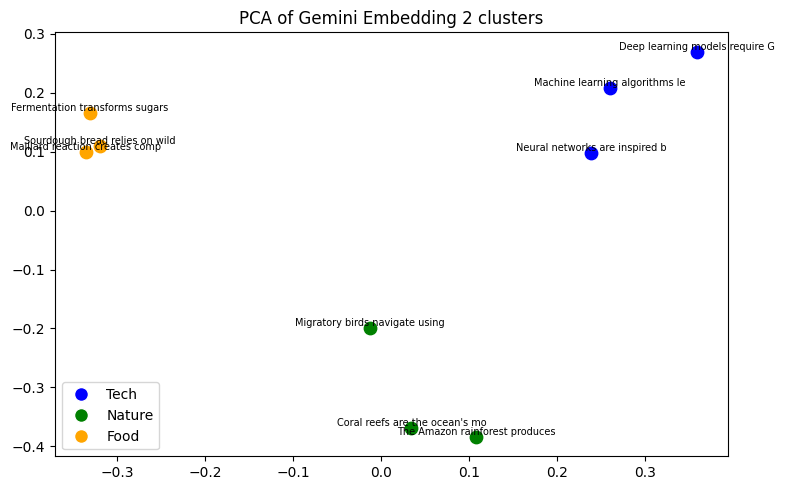

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

sample_texts = [
    # Technology cluster
    "Machine learning algorithms learn from data.",
    "Neural networks are inspired by the human brain.",
    "Deep learning models require GPUs for training.",
    # Nature cluster
    "The Amazon rainforest produces 20% of the world's oxygen.",
    "Coral reefs are the ocean's most biodiverse ecosystems.",
    "Migratory birds navigate using Earth's magnetic field.",
    # Food cluster
    "Fermentation transforms sugars into acids and gases.",
    "Maillard reaction creates complex flavors when food is browned.",
    "Sourdough bread relies on wild yeast and bacteria cultures.",
]

labels = ["Tech"] * 3 + ["Nature"] * 3 + ["Food"] * 3

result = client.models.embed_content(
    model=MODEL,
    contents=sample_texts,
    config=types.EmbedContentConfig(task_type="CLUSTERING", output_dimensionality=768)
)

vectors = np.array([e.values for e in result.embeddings])
reduced = PCA(n_components=2).fit_transform(vectors)

color_map = {"Tech": "blue", "Nature": "green", "Food": "orange"}
fig, ax = plt.subplots(figsize=(8, 5))
for i, (x, y) in enumerate(reduced):
    ax.scatter(x, y, color=color_map[labels[i]], s=80)
    ax.annotate(sample_texts[i][:30], (x, y), fontsize=7, ha="center", va="bottom")

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=l)
           for l, c in color_map.items()]
ax.legend(handles=handles)
ax.set_title("PCA of Gemini Embedding 2 clusters")
plt.tight_layout()
plt.show()

## 9. Batch Embeddings

When latency is not a concern, the Batch API processes embeddings asynchronously at **50% of the standard price**. This is ideal for large-scale indexing jobs.

See the [Batch API docs](https://ai.google.dev/gemini-api/docs/batch-api#batch-embedding) for full setup. The pattern below shows the structure.

In [ ]:
# Batch embedding - structure example
# The Batch API accepts a JSONL file where each line is one request.
# Submit via the Batch API endpoint, poll for completion, then download results.

import json

large_corpus = [
    f"Document number {i}: This is sample content for batch embedding demonstration."
    for i in range(100)
]

# Build a JSONL batch request file
batch_requests = [
    {
        "key": f"req_{i}",
        "request": {
            "model": f"models/{MODEL}",
            "contents": [{"parts": [{"text": text}]}],
            "config": {"task_type": "RETRIEVAL_DOCUMENT", "output_dimensionality": 768}
        }
    }
    for i, text in enumerate(large_corpus)
]

# Write to JSONL
with open("batch_input.jsonl", "w") as f:
    for req in batch_requests:
        f.write(json.dumps(req) + "\n")

print(f"Wrote {len(batch_requests)} requests to batch_input.jsonl")
print("Submit via the Batch API to process at 50% of standard pricing.")

Wrote 100 requests to batch_input.jsonl
Submit via the Batch API to process at 50% of standard pricing.


## Migration from `gemini-embedding-001`

The embedding spaces of `gemini-embedding-001` and `gemini-embedding-2-preview` are **incompatible**. You cannot directly compare or mix embeddings from both models.

If you are upgrading:
1. Re-embed your entire corpus with `gemini-embedding-2-preview`.
2. Replace your stored vectors before switching query embeddings.
3. Do not use cosine similarity across models - results will be meaningless.

The benefit: `gemini-embedding-2-preview` adds multimodal support and achieves higher quality on standard text benchmarks.

In [ ]:
# Migration helper: re-embed documents in chunks to avoid rate limits

import time

def reembed_corpus(
    texts: list[str],
    chunk_size: int = 50,
    task_type: str = "RETRIEVAL_DOCUMENT",
    output_dimensionality: int = 768,
    delay_secs: float = 0.5
) -> list[list[float]]:
    all_vectors = []
    for i in range(0, len(texts), chunk_size):
        chunk = texts[i : i + chunk_size]
        result = client.models.embed_content(
            model=MODEL,
            contents=chunk,
            config=types.EmbedContentConfig(
                task_type=task_type,
                output_dimensionality=output_dimensionality
            )
        )
        all_vectors.extend([e.values for e in result.embeddings])
        time.sleep(delay_secs)
        print(f"Re-embedded {min(i + chunk_size, len(texts))}/{len(texts)}")
    return all_vectors


# Example usage:
# new_vectors = reembed_corpus(old_corpus)
print("reembed_corpus() helper defined. Call it with your existing corpus to migrate.")

reembed_corpus() helper defined. Call it with your existing corpus to migrate.


---

## Resources

- [Gemini Embedding 2 launch post](https://blog.google/innovation-and-ai/models-and-research/gemini-models/gemini-embedding-2/)
- [Embeddings API docs](https://ai.google.dev/gemini-api/docs/embeddings)
- [Batch API docs](https://ai.google.dev/gemini-api/docs/batch-api)
- [Official cookbook quickstart](https://github.com/google-gemini/cookbook/blob/main/quickstarts/Embeddings.ipynb)
- [Multimodal demo](https://findmemedia.lmm.ai/)

**Third-party vector store docs:** [ChromaDB](https://docs.trychroma.com/integrations/embedding-models/google-gemini) | [Qdrant](https://qdrant.tech/documentation/embeddings/gemini/) | [Weaviate](https://docs.weaviate.io/weaviate/model-providers/google) | [Pinecone](https://github.com/google-gemini/cookbook/blob/main/examples/langchain/Gemini_LangChain_QA_Pinecone_WebLoad.ipynb)